# Step 1: Import Required Libraries

In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE

# Step 2: Load Dataset

In [4]:
df = pd.read_csv("/content/Fraud.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (600612, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0      0.0             0.0  
1  M2044282225             0.0             0.0      0.0             0.0  
2   C553264065             0.0             0.0      1.0             0.0  
3    C38997010         21182.0             0.0      1.0             0.0  
4  M1230701703             0.0             0.0      0.0             0.0  


# Step 3: Encode Categorical Columns (Safe Approach)

In [5]:
cat_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", cat_cols.tolist())

# Only encode columns with low cardinality (e.g., fewer than 50 unique values)
safe_encode_cols = [col for col in cat_cols if df[col].nunique() < 50]

if safe_encode_cols:
    df = pd.get_dummies(df, columns=safe_encode_cols, drop_first=True)
else:
    print("No safe categorical columns to encode with get_dummies.")

Categorical columns: ['type', 'nameOrig', 'nameDest']


# Step 4: Data Cleaning

In [6]:
print(df.isnull().sum())
print(df.dtypes)
print(df.nunique())

step              0
amount            0
nameOrig          0
oldbalanceOrg     1
newbalanceOrig    1
nameDest          1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
type_CASH_OUT     0
type_DEBIT        0
type_PAYMENT      0
type_TRANSFER     0
dtype: int64
step                int64
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud           float64
isFlaggedFraud    float64
type_CASH_OUT        bool
type_DEBIT           bool
type_PAYMENT         bool
type_TRANSFER        bool
dtype: object
step                  34
amount            587565
nameOrig          600530
oldbalanceOrg     266951
newbalanceOrig    272964
nameDest          260779
oldbalanceDest    346273
newbalanceDest    210380
isFraud                2
isFlaggedFraud         1
type_CASH_OUT          2
type_DEBIT             2
type_PAYMENT           2
type

# Step 5: Outlier Detection

In [7]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {outliers} outliers")

step: 26978 outliers
amount: 31551 outliers
oldbalanceOrg: 105015 outliers
newbalanceOrig: 98030 outliers
oldbalanceDest: 73056 outliers
newbalanceDest: 66304 outliers
isFraud: 361 outliers
isFlaggedFraud: 0 outliers


# Step 6: Exploratory Data Analysis (EDA)

Column 'is_fraud' not found for countplot


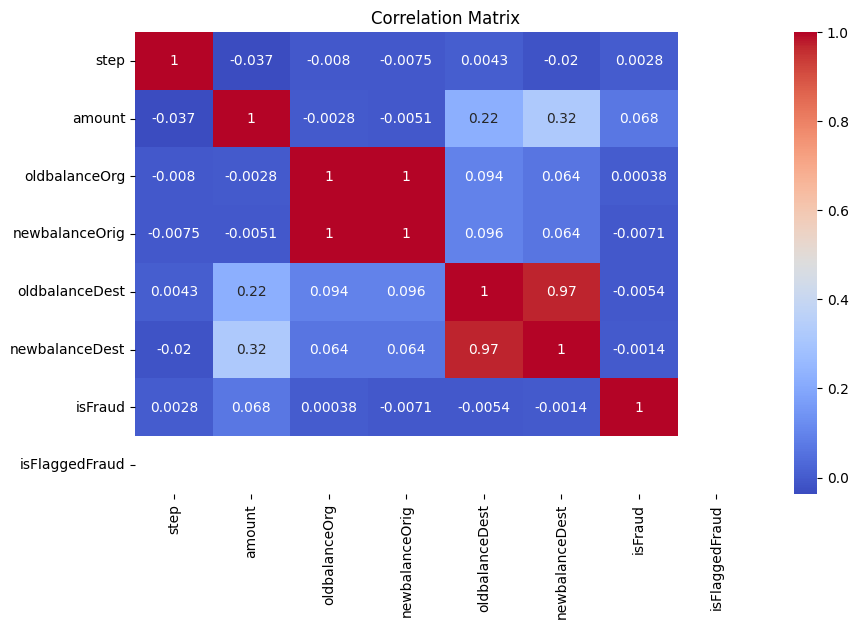

In [8]:
if 'is_fraud' in df.columns:
    sns.countplot(x=df['is_fraud'])
    plt.title("Class Balance")
    plt.show()
else:
    print("Column 'is_fraud' not found for countplot")

# Remove object columns to avoid correlation errors
eda_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(eda_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Step 7: Feature & Target Definition

In [9]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

# Step 8: Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 9: Apply SMOTE to Balance Classes

In [11]:
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test[X_train.columns]  # Align test set columns with train set

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Step 10: Feature Scaling

In [12]:
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

# Step 11: Initialize Classifiers

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300)
}

# Step 12: Train & Evaluate Models

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

optimized_models = {
    "Logistic Regression": Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=500))
    ]),

    "Random Forest": Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42))
    ]),

    "XGBoost": Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', XGBClassifier(n_estimators=50, max_depth=6, eval_metric='logloss', random_state=42, n_jobs=-1))
    ])
}

# Step 13: Compare Model Performance

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create DataFrame safely
metrics_df = pd.DataFrame({
    model: {
        'Accuracy': results[model]['Accuracy'],
        'F1 Score': results[model]['F1 Score'],
        'ROC AUC': results[model]['ROC AUC']
    } for model in results
}).T

# Step 2: Convert everything to numeric (fixes your error)
metrics_df = metrics_df.apply(pd.to_numeric, errors='coerce')

# Step 3: Drop any problematic rows (optional but safe)
metrics_df = metrics_df.dropna()

# Step 4: Print to verify
print(metrics_df)
print(metrics_df.dtypes)

# =========================
# 📊 Bar Plot
# =========================
metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# =========================
# 🔥 Bonus: Heatmap (Looks great in GitHub)
# =========================
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Model Performance Heatmap")
plt.show()

Empty DataFrame
Columns: []
Index: []
Series([], dtype: object)


TypeError: no numeric data to plot

# Step 14: XGBoost Feature Importance

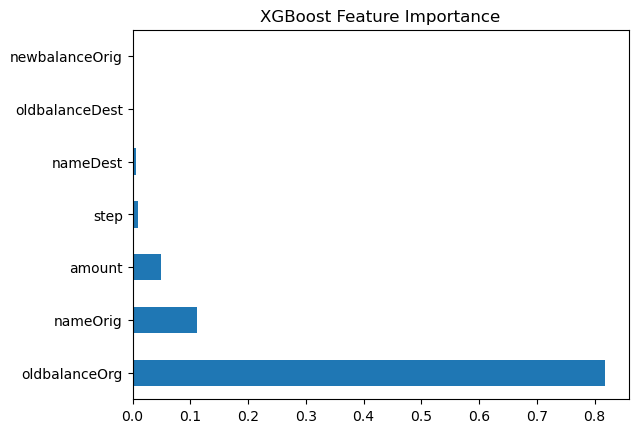

In [ ]:
xgb = optimized_models["XGBoost"]
feature_count = len(xgb.feature_importances_)
feature_names = X.columns[:feature_count]  # align feature names with importances
importances = pd.Series(xgb.feature_importances_, index=feature_names)
importances.nlargest(10).plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.show()

# Step 15: CatBoost Feature Importance

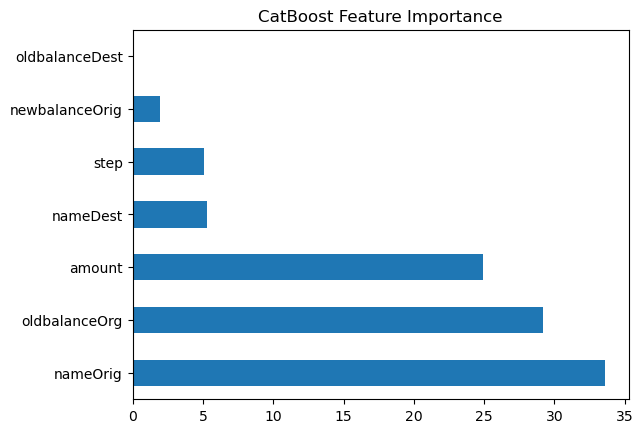

In [ ]:
catb = optimized_models["CatBoost"]
feature_count = len(catb.feature_importances_)
feature_names = X.columns[:feature_count]  # align feature names with importances
cat_importances = pd.Series(catb.feature_importances_, index=feature_names)
cat_importances.nlargest(10).plot(kind='barh')
plt.title("CatBoost Feature Importance")
plt.show()

# Step 16: Save Cleaned Dataset

In [ ]:
df.to_csv("cleaned_fraud_data.csv", index=False)

# Step 17: Final Model Summary Table

In [ ]:
print("\nModel Comparison Summary (Sorted by ROC AUC):")
print(metrics_df.sort_values("ROC AUC", ascending=False))


Model Comparison Summary (Sorted by ROC AUC):
                     Accuracy  F1 Score   ROC AUC
LightGBM             0.984343  0.139381  0.998279
CatBoost             0.981120  0.118145  0.998002
XGBoost              0.992688  0.256222  0.997964
Neural Network       0.988692  0.179815  0.997574
Random Forest        0.983076  0.127249  0.997052
Logistic Regression  0.967756  0.065899  0.978270
